In [1]:
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

DATA_PATH = "../outputs/cleaned_data.csv"
MODEL_OUT = "../models/best_lead_time_model.joblib"

In [2]:
df = pd.read_csv(DATA_PATH)

CATEGORICAL_FEATURES = ["Product Name", "Factory", "Region", "Ship Mode", "Division"]
NUMERIC_FEATURES = ["Shipping_Distance_KM", "Units"]
TARGET = "Lead Time"

X = df[CATEGORICAL_FEATURES + NUMERIC_FEATURES]
y = df[TARGET]

X.head()

,Product Name,Factory,Region,Ship Mode,Division,Shipping_Distance_KM,Units
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,Chocolate,1563.505335,2
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Standard Class,Chocolate,1160.081298,2
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,Standard Class,Chocolate,2188.313441,3
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,Standard Class,Chocolate,2188.313441,3
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,Chocolate,1008.215443,3


In [3]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_FEATURES),
        ("num", StandardScaler(), NUMERIC_FEATURES),
    ]
)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(8036, 7) (2009, 7)


In [5]:
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200, max_depth=10, random_state=42, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, max_depth=3, learning_rate=0.1, random_state=42
    ),
}

In [6]:
results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([("prep", preprocessor), ("model", model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"{name:20s} | RMSE: {rmse:.3f}  MAE: {mae:.3f}  R2: {r2:.3f}")
    results.append({"model": name, "rmse": rmse, "mae": mae, "r2": r2})
    fitted_pipelines[name] = pipe

Linear Regression    | RMSE: 0.618  MAE: 0.497  R2: 0.912
Random Forest        | RMSE: 0.625  MAE: 0.501  R2: 0.910
Gradient Boosting    | RMSE: 0.620  MAE: 0.500  R2: 0.912


In [7]:
# print(f"{'Model':20s} | {'Train R2':>10s} | {'Test R2':>10s} | {'Gap':>6s}")
# print("-" * 55)

# for name, pipe in fitted_pipelines.items():
#     train_preds = pipe.predict(X_train)
#     test_preds = pipe.predict(X_test)

#     train_r2 = r2_score(y_train, train_preds)
#     test_r2 = r2_score(y_test, test_preds)
#     gap = train_r2 - test_r2

#     print(f"{name:20s} | {train_r2:10.3f} | {test_r2:10.3f} | {gap:6.3f}")

In [8]:
results_df = pd.DataFrame(results).sort_values("rmse")
results_df

,model,rmse,mae,r2
0,Linear Regression,0.618001,0.496818,0.912141
2,Gradient Boosting,0.620205,0.499535,0.911514
1,Random Forest,0.625375,0.501328,0.910032


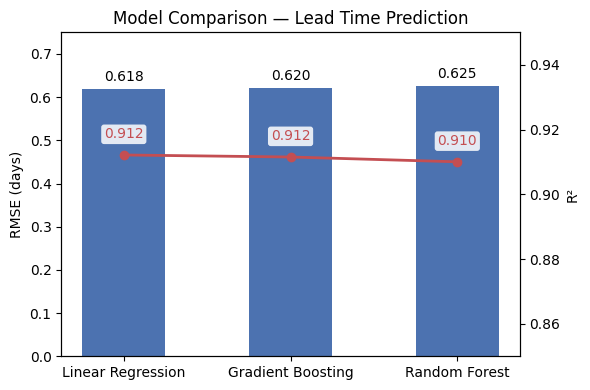

In [9]:
import matplotlib.pyplot as plt
import numpy as np

plt.close("all")

fig, ax1 = plt.subplots(figsize=(6, 4))
x = np.arange(len(results_df))

ax1.bar(x, results_df["rmse"], color="#4C72B0", width=0.5)
ax1.set_ylabel("RMSE (days)")
ax1.set_xticks(x)
ax1.set_xticklabels(results_df["model"])
ax1.set_ylim(0, 0.75)
for i, v in enumerate(results_df["rmse"]):
    ax1.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=10)

ax2 = ax1.twinx()
ax2.plot(x, results_df["r2"], color="#C44E52", marker="o", linewidth=2, zorder=3)
ax2.set_ylabel("R²")
ax2.set_ylim(0.85, 0.95)
for i, v in enumerate(results_df["r2"]):
    ax2.annotate(f"{v:.3f}", xy=(i, v), xytext=(0, 12), textcoords="offset points",
                 ha="center", fontsize=10, color="#C44E52",
                 bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.85))

ax1.set_title("Model Comparison — Lead Time Prediction")
fig.tight_layout()
plt.savefig("../outputs/fig1_model_comparison.png", dpi=150)
plt.show()

In [10]:
best_name = results_df.iloc[0]["model"]
best_pipeline = fitted_pipelines[best_name]
print(f"Best model: {best_name}")

joblib.dump(
    {
        "pipeline": best_pipeline,
        "model_name": best_name,
        "categorical_features": CATEGORICAL_FEATURES,
        "numeric_features": NUMERIC_FEATURES,
        "metrics": results_df.to_dict(orient="records"),
    },
    MODEL_OUT,
)
print(f"Saved to {MODEL_OUT}")

Best model: Linear Regression
Saved to ../models/best_lead_time_model.joblib


Random Forest

In [11]:
joblib.dump(
    {
        "pipeline": fitted_pipelines["Random Forest"],
        "model_name": "Random Forest",
        "categorical_features": CATEGORICAL_FEATURES,
        "numeric_features": NUMERIC_FEATURES,
    },
    "../models/random_forest_model.joblib",
)
print("Saved Random Forest model separately for comparison")

Saved Random Forest model separately for comparison


## Model selection note

Linear Regression has the best raw RMSE (0.618 vs. 0.625 for Random Forest) 
and is saved as the primary model (`best_lead_time_model.joblib`).

However, for the **factory reassignment simulation** specifically 
(`simulation.ipynb`), Random Forest is used instead. Diagnostic checks 
showed Linear Regression's Factory coefficients were disproportionately 
influenced by which specific low-volume products each factory happens to 
produce (a collinearity artifact), not genuine distance effects — e.g. 
recommending one factory in 100% of cases regardless of actual distance. 
Random Forest's feature importances confirmed it relies overwhelmingly 
on Ship Mode and Distance (as intended), with Factory/Product importance 
near zero — making it the safer choice for reassignment decisions, despite 
a marginally worse RMSE. See `random_forest_model.joblib`.